# Bongcloud adoption

Monthly count of Lichess games that reached the position after **1.e4 e5 2.Ke2**.

`lichess_api_data.json` comes from the Opening Explorer. Each `history` entry is a month with
three *outcome* counts — `white`, `draws`, `black` — so the number of games that
reached the position is their sum.

Fetched from API call below
```
https://explorer.lichess.ovh/lichess?variant=standard&play=e2e4,e7e5,e1e2&speeds=blitz&ratings=0,1000,1200,1400,1600,1800,2000,2200,2500,2700&history=true&moves=0&topGames=0&recentGames=0
```

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

with open("lichess_api_data.json") as f:
    data = json.load(f)

bongcloud_df = pd.DataFrame(data["history"])
bongcloud_df["games"] = bongcloud_df["white"] + bongcloud_df["draws"] + bongcloud_df["black"]
bongcloud_df["month"] = pd.to_datetime(bongcloud_df["month"])
bongcloud_df = bongcloud_df.sort_values("month")
bongcloud_df.head(5)


,month,white,draws,black,games
0,2013-01-01,0,0,1,1
1,2013-02-01,0,1,0,1
2,2013-03-01,0,0,0,0
3,2013-04-01,0,0,1,1
4,2013-05-01,0,0,0,0


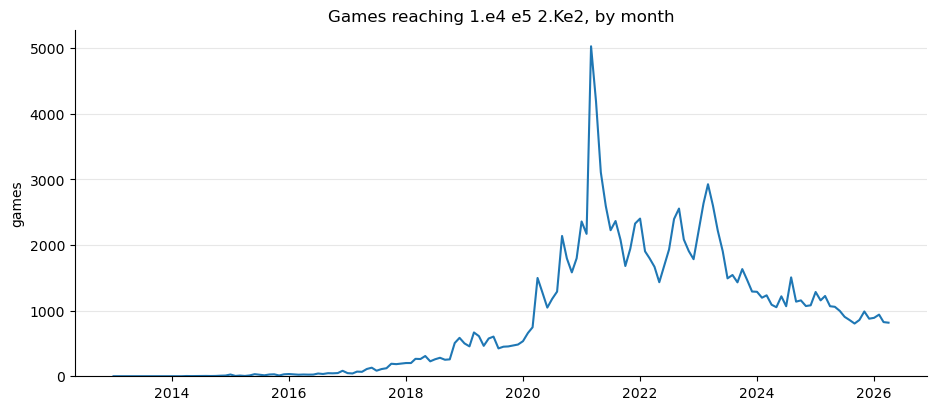

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(bongcloud_df["month"], bongcloud_df["games"], linewidth=1.5)

ax.set_title("Games reaching 1.e4 e5 2.Ke2, by month")
ax.set_ylabel("games")
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# write file to figures directory
plt.savefig("figures/bongcloud_df.png", dpi=300, bbox_inches="tight")
plt.show()

In [4]:
# Original dataa source: https://database.lichess.org/
bongcloud_data = pd.read_csv("bong_blitz.csv")
bongcloud_data.info()   
small_bongcloud_data = bongcloud_data.head(5)
small_bongcloud_data.to_csv("small_bong.csv", index=False)

print(f"Total number of games parsed from script: {len(bongcloud_data)}")
march_bongcloud_df = bongcloud_df[bongcloud_df["month"] == "2021-03-01"]
print(f"Number of games in March 2021 from API: {march_bongcloud_df['games'].values[0]}")

# print number of rows where opening = "Bongcloud Attack"
bongcloud_games = bongcloud_data[bongcloud_data['opening'] == "Bongcloud Attack"]
print(f"Number of games where opening is Bongcloud Attack as Parsed: {len(bongcloud_games)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5069 entries, 0 to 5068
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       5069 non-null   object
 1   white      5069 non-null   object
 2   white_elo  5069 non-null   int64 
 3   black      5069 non-null   object
 4   black_elo  5069 non-null   int64 
 5   opening    5069 non-null   object
dtypes: int64(2), object(4)
memory usage: 237.7+ KB
Total number of games parsed from script: 5069
Number of games in March 2021 from API: 5031
Number of games where opening is Bongcloud Attack as Parsed: 5069


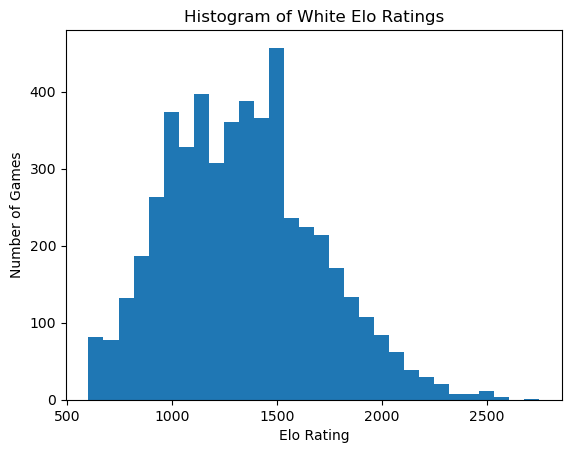

Mean of white_elo: 1336.254488064707


In [5]:
# plot histogram of white_elo
plt.hist(bongcloud_data['white_elo'], bins=30)

plt.title('Histogram of White Elo Ratings')
plt.xlabel('Elo Rating')
plt.ylabel('Number of Games')
# save the plot
plt.savefig("figures/white_elo_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Mean of white_elo: {bongcloud_data['white_elo'].mean()}")